# Play Tennis — Categorical Naive Bayes

Predict whether a person plays tennis from four weather features, then compare Naive Bayes against a Decision Tree and Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Load the data

The `No` column is just a row index, so drop it.

In [2]:
df = pd.read_csv("data/lab_8_data.csv").drop(columns=["No"])
print("Shape:", df.shape)
df.head()

Shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [3]:
print(df.isna().sum().to_string())
print()
for c in df.columns:
    print(f"{c}: {list(df[c].unique())}")

Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0

Outlook: ['Sunny', 'Overcast', 'Rain']
Temperature: ['Hot', 'Mild', 'Cool']
Humidity: ['High', 'Normal']
Wind: ['Weak', 'Strong']
Play Tennis: ['No', 'Yes']


50 rows, four categorical features, one categorical target, no missing values. Wind is Weak/Strong here, so the target case uses Wind = Strong.

## Explore the target and features

Check class balance and how each feature leans before trusting the model.

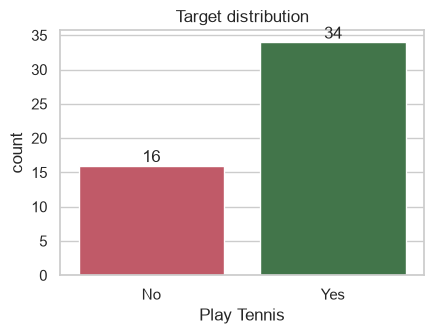

Play Tennis
Yes    34
No     16


In [4]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
order = ["No", "Yes"]
sns.countplot(x="Play Tennis", data=df, order=order, hue="Play Tennis",
              palette=["#d1495b", "#3a7d44"], legend=False, ax=ax)
ax.set_title("Target distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(df["Play Tennis"].value_counts().to_string())

Observations:
- Yes = 34, No = 16, roughly a 2:1 imbalance.
- Always guessing Yes already scores 68%, so accuracy alone is not enough.

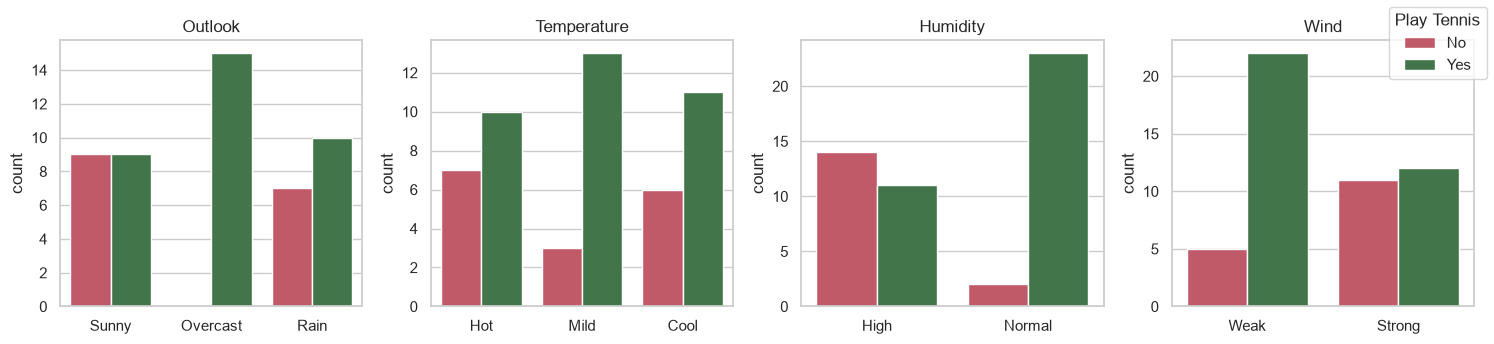

In [5]:
features = ["Outlook", "Temperature", "Humidity", "Wind"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, features):
    sns.countplot(x=col, hue="Play Tennis", data=df, hue_order=order,
                  palette=["#d1495b", "#3a7d44"], ax=ax)
    ax.set_title(col); ax.set_xlabel(""); ax.legend_.remove()
axes[0].set_ylabel("count")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Play Tennis", loc="upper right")
plt.tight_layout(); plt.show()

Observations:
- Overcast is almost always Yes; Sunny is the most split and leans No.
- Normal humidity and Weak wind lean Yes; High humidity and Strong wind lean No.
- Outlook and Humidity look like the strongest signals.

## Separate features and target

In [6]:
X = df[features]
y = df["Play Tennis"]
print("X columns:", list(X.columns))
print("y name    :", y.name)

X columns: ['Outlook', 'Temperature', 'Humidity', 'Wind']
y name    : Play Tennis


## Encode categories to numbers

The models need numeric input, so map each category to an integer with OrdinalEncoder; CategoricalNB treats them as labels, not ordered values.

In [7]:
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

for col, cats in zip(features, encoder.categories_):
    print(f"{col}: " + ", ".join(f"{c}->{i}" for i, c in enumerate(cats)))
pd.DataFrame(X_encoded, columns=features).head()

Outlook: Overcast->0, Rain->1, Sunny->2
Temperature: Cool->0, Hot->1, Mild->2
Humidity: High->0, Normal->1
Wind: Strong->0, Weak->1


,Outlook,Temperature,Humidity,Wind
0,2.0,1.0,0.0,1.0
1,2.0,1.0,0.0,0.0
2,0.0,1.0,0.0,1.0
3,1.0,2.0,0.0,1.0
4,1.0,0.0,1.0,1.0


## Train / test split

80/20 split, fixed seed for reproducibility, stratified to keep the Yes/No ratio in both parts.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape[0], "rows   Test:", X_test.shape[0], "rows")
print("Train balance:", y_train.value_counts().to_dict())
print("Test  balance:", y_test.value_counts().to_dict())

Train: 40 rows   Test: 10 rows
Train balance: {'Yes': 27, 'No': 13}
Test  balance: {'Yes': 7, 'No': 3}


## Train Categorical Naive Bayes

Set `min_categories` from the full data so every category has a slot even if it is missing from the training split.

In [9]:
min_cats = (X_encoded.max(axis=0) + 1).astype(int)
nb = CategoricalNB(min_categories=min_cats)
nb.fit(X_train, y_train)
print("Classes:", nb.classes_)
print("Class priors:", np.exp(nb.class_log_prior_).round(3))

Classes: ['No' 'Yes']
Class priors: [0.325 0.675]


## Predict and score on the test set

In [10]:
y_pred = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Naive Bayes test accuracy: {acc:.3f}")
pd.DataFrame({"actual": y_test.values, "predicted": y_pred})

Naive Bayes test accuracy: 0.900


,actual,predicted
0,No,Yes
1,Yes,Yes
2,No,No
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,No,No
9,Yes,Yes


## Confusion matrix

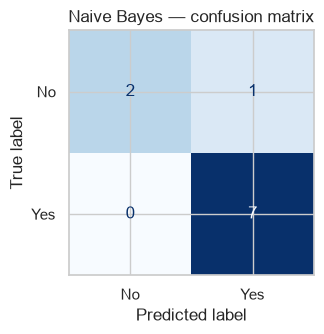

In [11]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=nb.classes_),
    display_labels=nb.classes_).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Naive Bayes — confusion matrix")
plt.tight_layout(); plt.show()

Observations:
- Diagonal = correct calls, off-diagonal = mistakes.
- Only 10 test rows, so each error shifts accuracy by 10 points.

## Classification report

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



Observations:
- Per-class precision/recall/F1 shown for Yes and No.
- Macro average weights both classes equally, a fairer read than accuracy on imbalanced data.

## Predict the requested weather case

Outlook = Sunny, Temperature = Cool, Humidity = High, Wind = Strong. Encode with the same mapping before predicting.

In [13]:
new_case = pd.DataFrame([{
    "Outlook": "Sunny", "Temperature": "Cool",
    "Humidity": "High", "Wind": "Strong"}])
new_encoded = encoder.transform(new_case)

pred = nb.predict(new_encoded)[0]
proba = nb.predict_proba(new_encoded)[0]
prob = dict(zip(nb.classes_, proba.round(3)))

print("Predicted class:", pred)
print("Probabilities  :", prob)

Predicted class: No
Probabilities  : {np.str_('No'): np.float64(0.789), np.str_('Yes'): np.float64(0.211)}


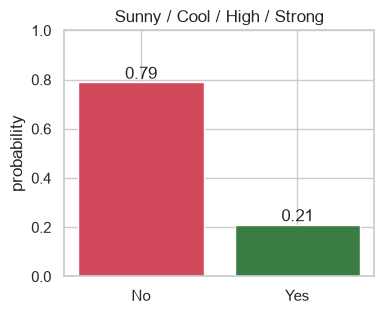

In [14]:
fig, ax = plt.subplots(figsize=(4, 3.3))
colors = {"No": "#d1495b", "Yes": "#3a7d44"}
ax.bar(nb.classes_, proba, color=[colors[c] for c in nb.classes_])
for i, v in enumerate(proba):
    ax.annotate(f"{v:.2f}", (i, v), ha="center", va="bottom")
ax.set_ylim(0, 1); ax.set_ylabel("probability")
ax.set_title("Sunny / Cool / High / Strong")
plt.tight_layout(); plt.show()

Observations:
- Predicted No.
- Sunny, High humidity and Strong wind all lean No in the EDA, so the call is consistent.

## Compare with Decision Tree and Logistic Regression

Same split and same encoding for all three, so any difference is down to the model.

In [15]:
models = {
    "Naive Bayes": nb,
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

rows = []
for name, m in models.items():
    if name != "Naive Bayes":
        m.fit(X_train, y_train)
    p = m.predict(X_test)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, p),
        "case_prediction": m.predict(new_encoded)[0],
    })
results = pd.DataFrame(rows)
results

,model,accuracy,case_prediction
0,Naive Bayes,0.9,No
1,Decision Tree,1.0,No
2,Logistic Regression,0.9,No


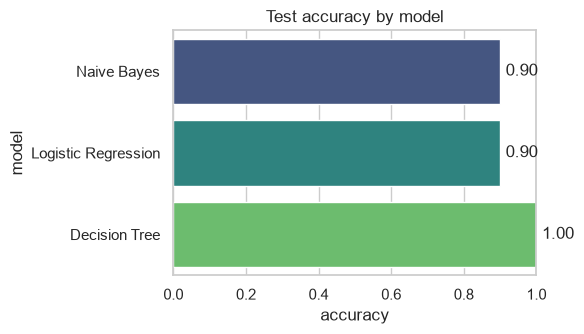

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x="accuracy", y="model", data=results.sort_values("accuracy"),
            hue="model", palette="viridis", legend=False, ax=ax)
ax.set_xlim(0, 1); ax.set_title("Test accuracy by model")
for i, v in enumerate(results.sort_values("accuracy")["accuracy"]):
    ax.annotate(f"{v:.2f}", (v, i), va="center", xytext=(4, 0),
                textcoords="offset points")
plt.tight_layout(); plt.show()

Observations:
- All three predict No for the requested case.
- Decision Tree scores highest, Naive Bayes and Logistic Regression tie behind it.

## Summary

- CategoricalNB fits this data naturally (all features are unordered categories), scores well, and predicts No for Sunny/Cool/High/Strong, matching the EDA.

Which to pick:
- Naive Bayes — small categorical datasets where you want fast training and probability estimates.
- Decision Tree — when you want readable if/then rules and can accept overfitting on tiny data (it hit the top score here by memorising rules).
- Logistic Regression — a linear baseline, but weakest here since encoded categories are not truly ordered; prefer it with one-hot encoding.